# 07 Your First Deep Learning Project in Python with Keras Step-By-Step

#### Source:

This practical is based on the blog post:

https://machinelearningmastery.com/tutorial-first-neural-network-python-keras/

Here we are going to reproduce parts of that post.
I recommend using Anaconda Python, read the installation guide for it under Unit 7. Use Python 3.x.



### Prerequisites:
Libraries used in this tutorial:
- keras (now built into TensorFlow)
- numpy
- sklearn
- pydot

External libraries (necessary for visualization):
- https://graphviz.gitlab.io/download/

If you set up your machine at home you can remove the cell below

In [1]:
!pip install pydot
!pip install graphviz
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


#### Datasets used
Please download the following datasets and put them into the folder, where this notebook is located (i.e. your working directory):
- https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
- http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
- https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data

### Install Tensorflow:

In [2]:
import tensorflow as tf
from tensorflow import keras


In [3]:
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense

# For plotting layers import one of these two:
#from keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import plot_model


import pydot
import matplotlib.pyplot as plt

#### Load the Pima Indian dataset

It is a csv file with ',' as delimiter.

In [4]:
# load the dataset
dataset = loadtxt('pima-indians-diabetes.data.csv', delimiter=',')

The variables can be summarized as follows:

Input Variables (X):

1. Number of times pregnant
2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test
3. Diastolic blood pressure (mm Hg)
4. Triceps skin fold thickness (mm)
5. 2-Hour serum insulin (mu U/ml)
6. Body mass index (weight in kg/(height in m)^2)
7. Diabetes pedigree function
8. Age (years)

Output Variables (Y):

1. Class variable (0 or 1)

# Task 0
What is the size of this dataset? Take a look at a few rows of this dataset to make sure you understand the structure of the data.

In [5]:
# Separate the dataset into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]

- The model expects rows of data with 8 variables (the input_dim=8 argument)
- The first hidden layer has 12 nodes and uses the relu activation function.
- The second hidden layer has 8 nodes and uses the relu activation function.
- The output layer has one node and uses the sigmoid activation function.

In [6]:
# define the Keras model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
#model.add(Dense(1, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

In [7]:
#Check your model 
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 12)                108       
                                                                 
 dense_1 (Dense)             (None, 8)                 104       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 221 (884.00 Byte)
Trainable params: 221 (884.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


To train a neural network model you will need to specify a loss function, an optimizer, and some metrics for monitoring.

https://www.tensorflow.org/guide/keras/train_and_evaluate/

In [8]:
# compile the Keras model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
# fit the Keras model on the dataset
history = model.fit(X, Y, epochs=150, batch_size=10)

Epoch 1/150


77/77 [==============================] - 2s 3ms/step - loss: 16.5499 - accuracy: 0.6315
Epoch 2/150
77/77 [==============================] - 0s 3ms/step - loss: 4.7445 - accuracy: 0.5495
Epoch 3/150
77/77 [==============================] - 0s 2ms/step - loss: 1.1641 - accuracy: 0.6146
Epoch 4/150
77/77 [==============================] - 0s 3ms/step - loss: 0.8013 - accuracy: 0.6536
Epoch 5/150
77/77 [==============================] - 0s 3ms/step - loss: 0.7501 - accuracy: 0.6523
Epoch 6/150
77/77 [==============================] - 0s 3ms/step - loss: 0.7286 - accuracy: 0.6406
Epoch 7/150
77/77 [==============================] - 0s 3ms/step - loss: 0.6602 - accuracy: 0.6693
Epoch 8/150
77/77 [==============================] - 0s 3ms/step - loss: 0.6417 - accuracy: 0.6641
Epoch 9/150
77/77 [==============================] - 0s 3ms/step - loss: 0.6514 - accuracy: 0.6680
Epoch 10/150
77/77 [==============================] - 0s 3ms/step - loss: 0.6230 - accuracy: 0.6771
Epoch 

77/77 [==============================] - 0s 3ms/step - loss: 0.5216 - accuracy: 0.7513
Epoch 79/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5219 - accuracy: 0.7409
Epoch 80/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5406 - accuracy: 0.7357
Epoch 81/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5268 - accuracy: 0.7396
Epoch 82/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5301 - accuracy: 0.7409
Epoch 83/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5184 - accuracy: 0.7565
Epoch 84/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5466 - accuracy: 0.7331
Epoch 85/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5255 - accuracy: 0.7422
Epoch 86/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5335 - accuracy: 0.7383
Epoch 87/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5193 - accuracy: 0.7474
Epoch 88/150


In [10]:
# evaluate the keras model
_, accuracy = model.evaluate(X, Y)
print('Accuracy: %.2f' % (accuracy*100))

24/24 [==============================] - 0s 3ms/step - loss: 0.4877 - accuracy: 0.7656
Accuracy: 76.56


In [11]:
# Plot model
plot_model(model, show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


Text(0, 0.5, 'Cross entropy loss')

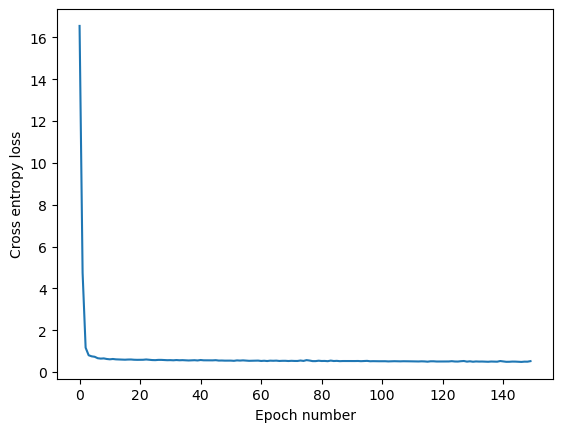

In [22]:
#Plot history
plt.plot(history.history['loss'], label='binary cross entropy loss')
plt.xlabel('Epoch number')
plt.ylabel('Cross entropy loss')

## Predictions

In [13]:
# make probability predictions with the model
predictions = model.predict(X)
# round predictions 
rounded = [round(x[0]) for x in predictions]

24/24 [==============================] - 0s 2ms/step


# Task 1
Create another model (give it a different name) with a slightly different architecture, e.g. with a different number of neurons in the two hidden layers. Specify how many neurons in each layer. Add an extra hidden layer.

In [14]:
#Please post your solution here.
#Feel free to add markdown and code cells as you need

# New Keras model 
model2 = Sequential()

# Adding the first hidden layer with a different number of neurons
model2.add(Dense(16, input_dim=8, activation='relu'))

# Add an extra hidden layer with a different number of neurons
model2.add(Dense(12, activation='relu'))

# Add the third hidden layer (unchanged)
model2.add(Dense(8, activation='relu'))

# Add the output layer (binary classification)
model2.add(Dense(1, activation='sigmoid'))

# Task 2

Split the data into a training set (80%) and a validation set (20%), by setting the *validation_split* parameter appropriately in the Keras model. 


In [ ]:
from sklearn.model_selection import train_test_split
#Please post your solution here.
#Feel free to add markdown and code cells as you need
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
# Compile the model
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history1 = model2.fit(X_train, Y_train, epochs=150, batch_size=10, validation_split=0.2)

Epoch 1/150
50/50 [==============================] - 1s 8ms/step - loss: 0.4587 - accuracy: 0.7923 - val_loss: 0.5806 - val_accuracy: 0.7317
Epoch 2/150
50/50 [==============================] - 0s 4ms/step - loss: 0.4611 - accuracy: 0.7963 - val_loss: 0.5836 - val_accuracy: 0.7236
Epoch 3/150
50/50 [==============================] - 0s 4ms/step - loss: 0.4681 - accuracy: 0.7821 - val_loss: 0.6532 - val_accuracy: 0.6748
Epoch 4/150
50/50 [==============================] - 0s 5ms/step - loss: 0.4575 - accuracy: 0.7699 - val_loss: 0.5449 - val_accuracy: 0.7154
Epoch 5/150
50/50 [==============================] - 0s 5ms/step - loss: 0.4627 - accuracy: 0.7800 - val_loss: 0.5357 - val_accuracy: 0.7317
Epoch 6/150
50/50 [==============================] - 0s 5ms/step - loss: 0.4457 - accuracy: 0.7862 - val_loss: 0.6071 - val_accuracy: 0.7154
Epoch 7/150
50/50 [==============================] - 0s 5ms/step - loss: 0.4514 - accuracy: 0.7841 - val_loss: 0.5931 - val_accuracy: 0.7154
Epoch 8/150
5

Epoch 59/150
50/50 [==============================] - 0s 5ms/step - loss: 0.4295 - accuracy: 0.7984 - val_loss: 0.5566 - val_accuracy: 0.7398
Epoch 60/150
50/50 [==============================] - 0s 5ms/step - loss: 0.3976 - accuracy: 0.8269 - val_loss: 0.5415 - val_accuracy: 0.7724
Epoch 61/150
50/50 [==============================] - 0s 4ms/step - loss: 0.4035 - accuracy: 0.7963 - val_loss: 0.5247 - val_accuracy: 0.7642
Epoch 62/150
50/50 [==============================] - 0s 5ms/step - loss: 0.4000 - accuracy: 0.8065 - val_loss: 0.5849 - val_accuracy: 0.6911
Epoch 63/150
50/50 [==============================] - 0s 4ms/step - loss: 0.4161 - accuracy: 0.8228 - val_loss: 0.6331 - val_accuracy: 0.6992
Epoch 64/150
50/50 [==============================] - 0s 4ms/step - loss: 0.4364 - accuracy: 0.7963 - val_loss: 0.5526 - val_accuracy: 0.7317
Epoch 65/150
50/50 [==============================] - 0s 5ms/step - loss: 0.4094 - accuracy: 0.8187 - val_loss: 0.5817 - val_accuracy: 0.7236
Epoch 

# Task 3 

Visualize the performance of your model during training by using the history dictionary object (part of model.fit()). Plot training loss and validation loss against Epoch.

In [ ]:
#Please post your solution here.
#Feel free to add markdown and code cells as you need
# fit the Keras model on the dataset
# Fit the model with validation split
#Plot history
plt.plot(history1.history['loss'], label='Training Loss')
plt.xlabel('Epoch number')
plt.ylabel('Training Loss')

# Task 4

Using your model from *Task 1* change the activation functions and see how this affects training.

In [17]:
#Please post your solution here.
#Feel free to add markdown and code cells as you need
model2_changed = Sequential()

# Change activation functions in the hidden layers
model2_changed.add(Dense(16, input_dim=8, activation='tanh'))  # Changed to tanh
model2_changed.add(Dense(12, activation='sigmoid'))  # Changed to sigmoid
model2_changed.add(Dense(8, activation='relu'))  # Kept relu in the third hidden layer

# Add the output layer (binary classification)
model2_changed.add(Dense(1, activation='sigmoid'))

# Compile the model
model2_changed.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history2 = model2_changed.fit(X_train, Y_train, epochs=150, batch_size=10, validation_split=0.2)



Epoch 1/150
50/50 [==============================] - 1s 7ms/step - loss: 0.6444 - accuracy: 0.6721 - val_loss: 0.6491 - val_accuracy: 0.6098
Epoch 2/150
50/50 [==============================] - 0s 4ms/step - loss: 0.6242 - accuracy: 0.6640 - val_loss: 0.6451 - val_accuracy: 0.6098
Epoch 3/150
50/50 [==============================] - 0s 5ms/step - loss: 0.6193 - accuracy: 0.6640 - val_loss: 0.6398 - val_accuracy: 0.6179
Epoch 4/150
50/50 [==============================] - 0s 5ms/step - loss: 0.6155 - accuracy: 0.6721 - val_loss: 0.6332 - val_accuracy: 0.6179
Epoch 5/150
50/50 [==============================] - 0s 5ms/step - loss: 0.6093 - accuracy: 0.6640 - val_loss: 0.6317 - val_accuracy: 0.6260
Epoch 6/150
50/50 [==============================] - 0s 4ms/step - loss: 0.6063 - accuracy: 0.6660 - val_loss: 0.6280 - val_accuracy: 0.6423
Epoch 7/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5996 - accuracy: 0.6721 - val_loss: 0.6356 - val_accuracy: 0.6098
Epoch 8/150
5

Epoch 59/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5175 - accuracy: 0.7352 - val_loss: 0.5818 - val_accuracy: 0.7236
Epoch 60/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5146 - accuracy: 0.7373 - val_loss: 0.5767 - val_accuracy: 0.7236
Epoch 61/150
50/50 [==============================] - 0s 4ms/step - loss: 0.5151 - accuracy: 0.7271 - val_loss: 0.5830 - val_accuracy: 0.7317
Epoch 62/150
50/50 [==============================] - 0s 4ms/step - loss: 0.5125 - accuracy: 0.7393 - val_loss: 0.5791 - val_accuracy: 0.6911
Epoch 63/150
50/50 [==============================] - 0s 4ms/step - loss: 0.5102 - accuracy: 0.7495 - val_loss: 0.5912 - val_accuracy: 0.7073
Epoch 64/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5090 - accuracy: 0.7413 - val_loss: 0.5752 - val_accuracy: 0.7236
Epoch 65/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5210 - accuracy: 0.7230 - val_loss: 0.5867 - val_accuracy: 0.7073
Epoch 

50/50 [==============================] - 0s 5ms/step - loss: 0.4962 - accuracy: 0.7434 - val_loss: 0.5695 - val_accuracy: 0.7073
Epoch 117/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5011 - accuracy: 0.7454 - val_loss: 0.5791 - val_accuracy: 0.7154
Epoch 118/150
50/50 [==============================] - 0s 5ms/step - loss: 0.4979 - accuracy: 0.7434 - val_loss: 0.5824 - val_accuracy: 0.7073
Epoch 119/150
50/50 [==============================] - 0s 4ms/step - loss: 0.5024 - accuracy: 0.7352 - val_loss: 0.5853 - val_accuracy: 0.6911
Epoch 120/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5044 - accuracy: 0.7291 - val_loss: 0.5854 - val_accuracy: 0.7236
Epoch 121/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5056 - accuracy: 0.7393 - val_loss: 0.5819 - val_accuracy: 0.7236
Epoch 122/150
50/50 [==============================] - 0s 5ms/step - loss: 0.5136 - accuracy: 0.7271 - val_loss: 0.5962 - val_accuracy: 0.7236
Epoch 123/150

Text(0.5, 1.0, 'Training Loss for Changed activation function')

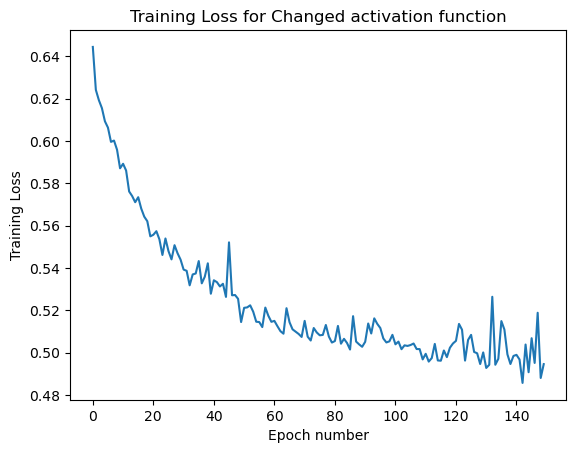

In [18]:
plt.plot(history2.history['loss'], label='Training Loss for Changed activation function')
plt.xlabel('Epoch number')
plt.ylabel('Training Loss')
plt.title('Training Loss for Changed activation function')

# Task 5

Increase the number of epochs. See what happens.

In [19]:
#Please post your solution here.
#Feel free to add markdown and code cells as you need

# Instantiate the model (Task 1 model)
model2_echo_changed = Sequential()
model2_echo_changed.add(Dense(16, input_dim=8, activation='relu'))
model2_echo_changed.add(Dense(12, activation='relu'))
model2_echo_changed.add(Dense(8, activation='relu'))
model2_echo_changed.add(Dense(1, activation='sigmoid'))

# Compile the model
model2_echo_changed.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history3 = model2_echo_changed.fit(X_train, Y_train, epochs=200, batch_size=10, validation_split=0.2)

Epoch 1/200
50/50 [==============================] - 1s 8ms/step - loss: 2.5402 - accuracy: 0.5031 - val_loss: 1.0659 - val_accuracy: 0.5772
Epoch 2/200
50/50 [==============================] - 0s 5ms/step - loss: 0.9347 - accuracy: 0.6314 - val_loss: 0.7937 - val_accuracy: 0.6341
Epoch 3/200
50/50 [==============================] - 0s 5ms/step - loss: 0.7281 - accuracy: 0.6660 - val_loss: 0.7264 - val_accuracy: 0.6748
Epoch 4/200
50/50 [==============================] - 0s 5ms/step - loss: 0.7565 - accuracy: 0.6599 - val_loss: 0.7355 - val_accuracy: 0.6504
Epoch 5/200
50/50 [==============================] - 0s 4ms/step - loss: 0.6477 - accuracy: 0.6945 - val_loss: 0.6857 - val_accuracy: 0.6748
Epoch 6/200
50/50 [==============================] - 0s 5ms/step - loss: 0.6394 - accuracy: 0.6864 - val_loss: 0.6729 - val_accuracy: 0.6504
Epoch 7/200
50/50 [==============================] - 0s 5ms/step - loss: 0.6181 - accuracy: 0.7047 - val_loss: 0.6168 - val_accuracy: 0.6667
Epoch 8/200
5

Epoch 59/200
50/50 [==============================] - 0s 5ms/step - loss: 0.5016 - accuracy: 0.7617 - val_loss: 0.6527 - val_accuracy: 0.6748
Epoch 60/200
50/50 [==============================] - 0s 5ms/step - loss: 0.5455 - accuracy: 0.7352 - val_loss: 0.5308 - val_accuracy: 0.7480
Epoch 61/200
50/50 [==============================] - 0s 5ms/step - loss: 0.5065 - accuracy: 0.7637 - val_loss: 0.5409 - val_accuracy: 0.7154
Epoch 62/200
50/50 [==============================] - 0s 6ms/step - loss: 0.6050 - accuracy: 0.7332 - val_loss: 0.6641 - val_accuracy: 0.6341
Epoch 63/200
50/50 [==============================] - 0s 4ms/step - loss: 0.5774 - accuracy: 0.7189 - val_loss: 0.5317 - val_accuracy: 0.7561
Epoch 64/200
50/50 [==============================] - 0s 5ms/step - loss: 0.5078 - accuracy: 0.7475 - val_loss: 0.5543 - val_accuracy: 0.7561
Epoch 65/200
50/50 [==============================] - 0s 4ms/step - loss: 0.5034 - accuracy: 0.7617 - val_loss: 0.5437 - val_accuracy: 0.7154
Epoch 

50/50 [==============================] - 0s 5ms/step - loss: 0.5420 - accuracy: 0.7658 - val_loss: 0.5469 - val_accuracy: 0.7317
Epoch 117/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4750 - accuracy: 0.7821 - val_loss: 0.5565 - val_accuracy: 0.7073
Epoch 118/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4647 - accuracy: 0.7780 - val_loss: 0.5446 - val_accuracy: 0.7317
Epoch 119/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4674 - accuracy: 0.7800 - val_loss: 0.5390 - val_accuracy: 0.7236
Epoch 120/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4505 - accuracy: 0.7882 - val_loss: 0.5705 - val_accuracy: 0.7073
Epoch 121/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4705 - accuracy: 0.7902 - val_loss: 0.5295 - val_accuracy: 0.7317
Epoch 122/200
50/50 [==============================] - 0s 4ms/step - loss: 0.4504 - accuracy: 0.7821 - val_loss: 0.5398 - val_accuracy: 0.7236
Epoch 123/200

50/50 [==============================] - 0s 5ms/step - loss: 0.4477 - accuracy: 0.8065 - val_loss: 0.5328 - val_accuracy: 0.7236
Epoch 174/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4232 - accuracy: 0.8004 - val_loss: 0.5225 - val_accuracy: 0.7317
Epoch 175/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4343 - accuracy: 0.7963 - val_loss: 0.5141 - val_accuracy: 0.7398
Epoch 176/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4452 - accuracy: 0.7841 - val_loss: 0.5521 - val_accuracy: 0.7317
Epoch 177/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4282 - accuracy: 0.8065 - val_loss: 0.5249 - val_accuracy: 0.7236
Epoch 178/200
50/50 [==============================] - 0s 5ms/step - loss: 0.4561 - accuracy: 0.7699 - val_loss: 0.5408 - val_accuracy: 0.7398
Epoch 179/200
50/50 [==============================] - 0s 4ms/step - loss: 0.5034 - accuracy: 0.7617 - val_loss: 0.5377 - val_accuracy: 0.7317
Epoch 180/200

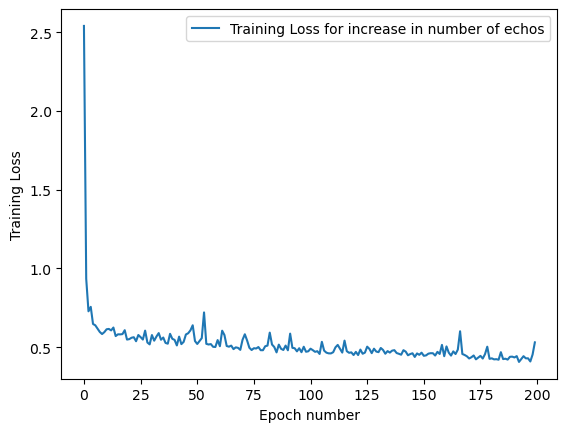

In [20]:
plt.plot(history3.history['loss'], label='Training Loss for increase in number of echos')
plt.xlabel('Epoch number')
plt.ylabel('Training Loss')
plt.legend()

# Task 6 (optional)

Try similar steps for the multiclass tutorial:

https://machinelearningmastery.com/multi-class-classification-tutorial-keras-deep-learning-library/